<a href="https://colab.research.google.com/github/Andrew-Neel/Energy-Consumption-Prediction/blob/main/Final_Capstone.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
!kaggle datasets download -d apollo2506/eurosat-dataset
!unzip eurosat-dataset.zip
!ls

Streaming output truncated to the last 5000 lines.
  inflating: EuroSATallBands/River/River_1991.tif  
  inflating: EuroSATallBands/River/River_1992.tif  
  inflating: EuroSATallBands/River/River_1993.tif  
  inflating: EuroSATallBands/River/River_1994.tif  
  inflating: EuroSATallBands/River/River_1995.tif  
  inflating: EuroSATallBands/River/River_1996.tif  
  inflating: EuroSATallBands/River/River_1997.tif  
  inflating: EuroSATallBands/River/River_1998.tif  
  inflating: EuroSATallBands/River/River_1999.tif  
  inflating: EuroSATallBands/River/River_2.tif  
  inflating: EuroSATallBands/River/River_20.tif  
  inflating: EuroSATallBands/River/River_200.tif  
  inflating: EuroSATallBands/River/River_2000.tif  
  inflating: EuroSATallBands/River/River_2001.tif  
  inflating: EuroSATallBands/River/River_2002.tif  
  inflating: EuroSATallBands/River/River_2003.tif  
  inflating: EuroSATallBands/River/River_2004.tif  
  inflating: EuroSATallBands/River/River_2005.tif  
  inflating: EuroSA

In [18]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
from tensorflow.keras.applications.resnet50 import ResNet50, preprocess_input
from PIL import Image

In [5]:
DATA_DIR = "/content/EuroSAT"

Class Distribution Analysis

In [3]:
class_counts = {}

for class_name in sorted(os.listdir(DATA_DIR)):
    class_path = os.path.join(DATA_DIR, class_name)

    if os.path.isdir(class_path):
        class_counts[class_name] = len(
            [f for f in os.listdir(class_path)
             if f.endswith((".jpg", ".jpeg", ".png", ".tif"))]
        )

df_counts = pd.DataFrame(
    class_counts.items(),
    columns=["Class", "Count"]
).sort_values("Count", ascending=False)

print(df_counts)

                  Class  Count
0            AnnualCrop   3000
1                Forest   3000
2  HerbaceousVegetation   3000
7           Residential   3000
9               SeaLake   3000
3               Highway   2500
6         PermanentCrop   2500
4            Industrial   2500
8                 River   2500
5               Pasture   2000


Images per Class

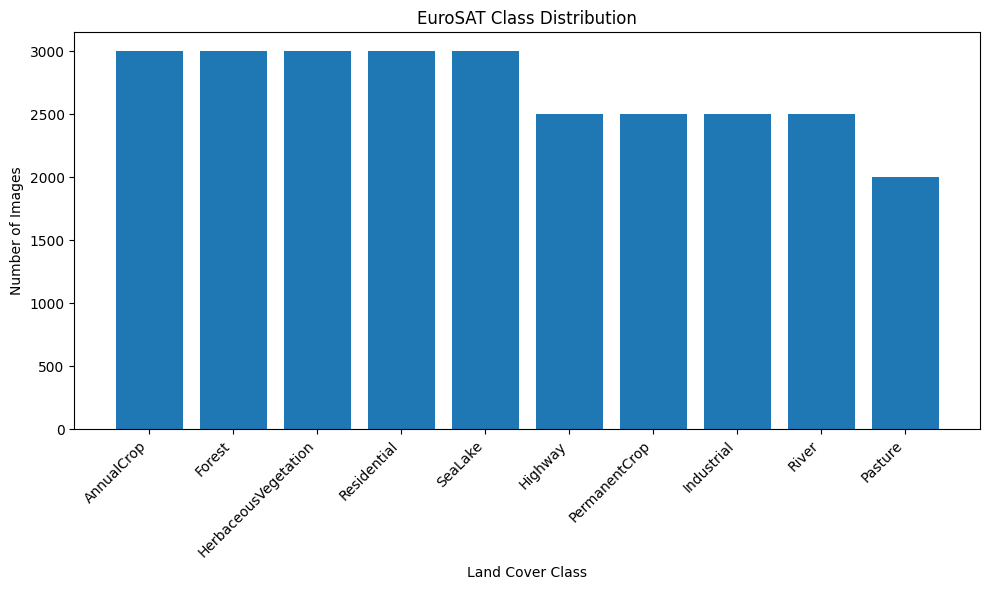

In [4]:
plt.figure(figsize=(10,6))

plt.bar(df_counts["Class"], df_counts["Count"])

plt.xticks(rotation=45, ha="right")
plt.ylabel("Number of Images")
plt.xlabel("Land Cover Class")
plt.title("EuroSAT Class Distribution")

plt.tight_layout()
plt.show()

Check Image Dimensions

In [5]:
sample_dimensions = []

for class_name in sorted(os.listdir(DATA_DIR)):
    class_path = os.path.join(DATA_DIR, class_name)

    if os.path.isdir(class_path):

        img_file = random.choice(os.listdir(class_path))
        img_path = os.path.join(class_path, img_file)

        img = Image.open(img_path)

        sample_dimensions.append(img.size)

print("Unique dimensions found:")
print(set(sample_dimensions))

Unique dimensions found:
{(64, 64)}


Display Sample Images

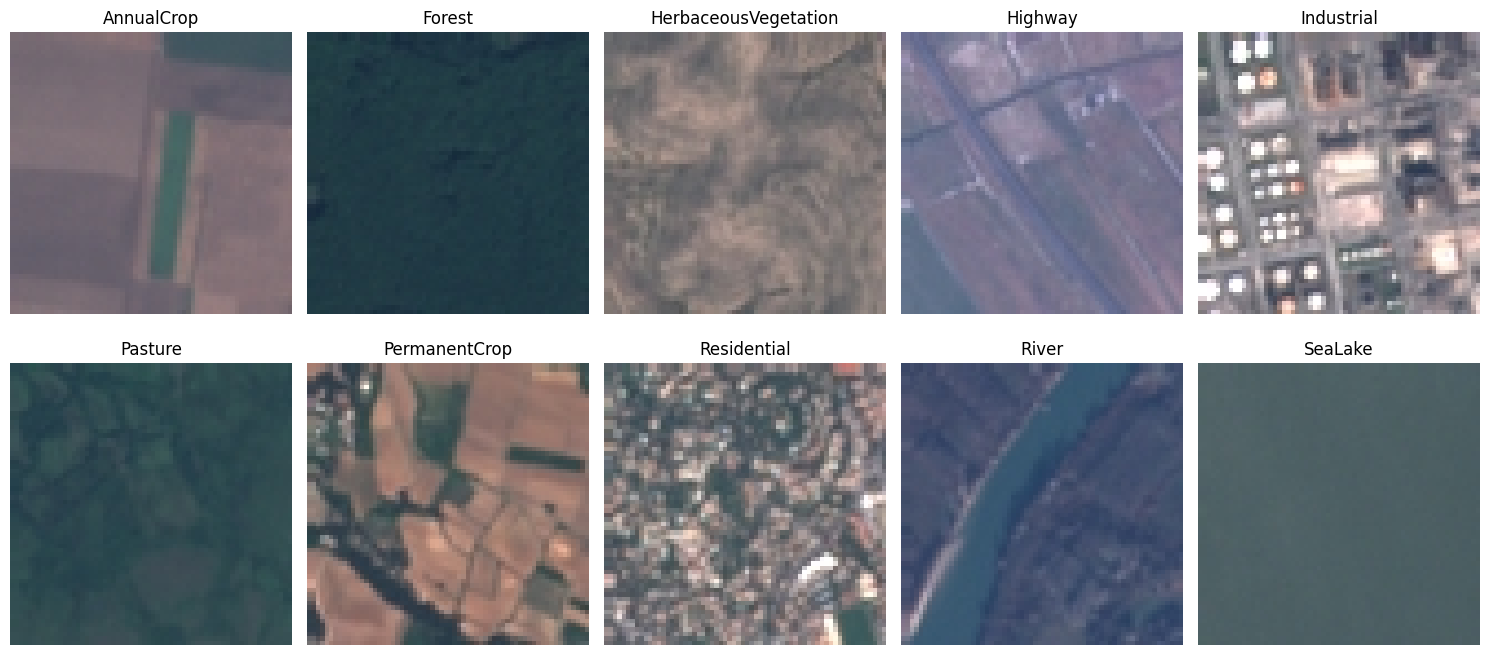

In [6]:
classes = sorted([
    d for d in os.listdir(DATA_DIR)
    if os.path.isdir(os.path.join(DATA_DIR, d))
])

fig, axes = plt.subplots(2, 5, figsize=(15, 7))

axes = axes.flatten()

for ax, class_name in zip(axes, classes):

    class_path = os.path.join(DATA_DIR, class_name)

    img_name = random.choice(os.listdir(class_path))
    img_path = os.path.join(class_path, img_name)

    img = Image.open(img_path)

    ax.imshow(img)
    ax.set_title(class_name)
    ax.axis("off")

plt.tight_layout()
plt.show()

Summary Statistics

In [7]:
total_images = sum(class_counts.values())
num_classes = len(class_counts)

print(f"Number of Classes: {num_classes}")
print(f"Total Images: {total_images}")
print(f"Average Images per Class: {total_images/num_classes:.1f}")

Number of Classes: 10
Total Images: 27000
Average Images per Class: 2700.0


Pixel Intensity Distribution

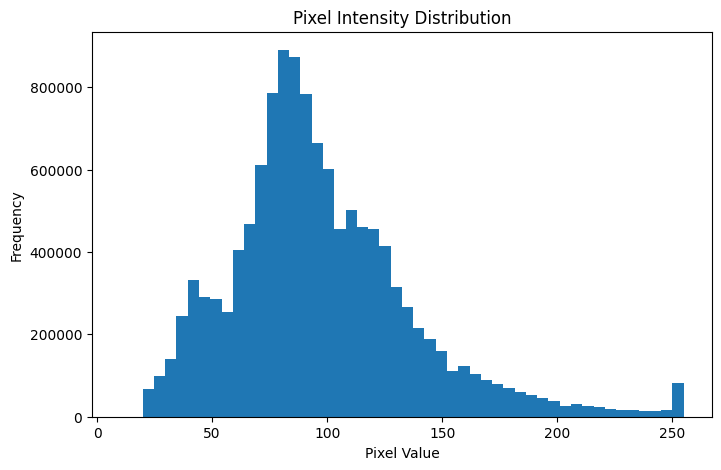

In [8]:
import numpy as np

all_pixels = []

for class_name in os.listdir(DATA_DIR):
    class_path = os.path.join(DATA_DIR, class_name)

    if os.path.isdir(class_path):

        files = os.listdir(class_path)[:100]  # sample

        for file in files:
            img = Image.open(os.path.join(class_path, file))
            img = np.array(img)

            all_pixels.extend(img.flatten())

plt.figure(figsize=(8,5))
plt.hist(all_pixels, bins=50)
plt.title("Pixel Intensity Distribution")
plt.xlabel("Pixel Value")
plt.ylabel("Frequency")
plt.show()

Average Image per Class

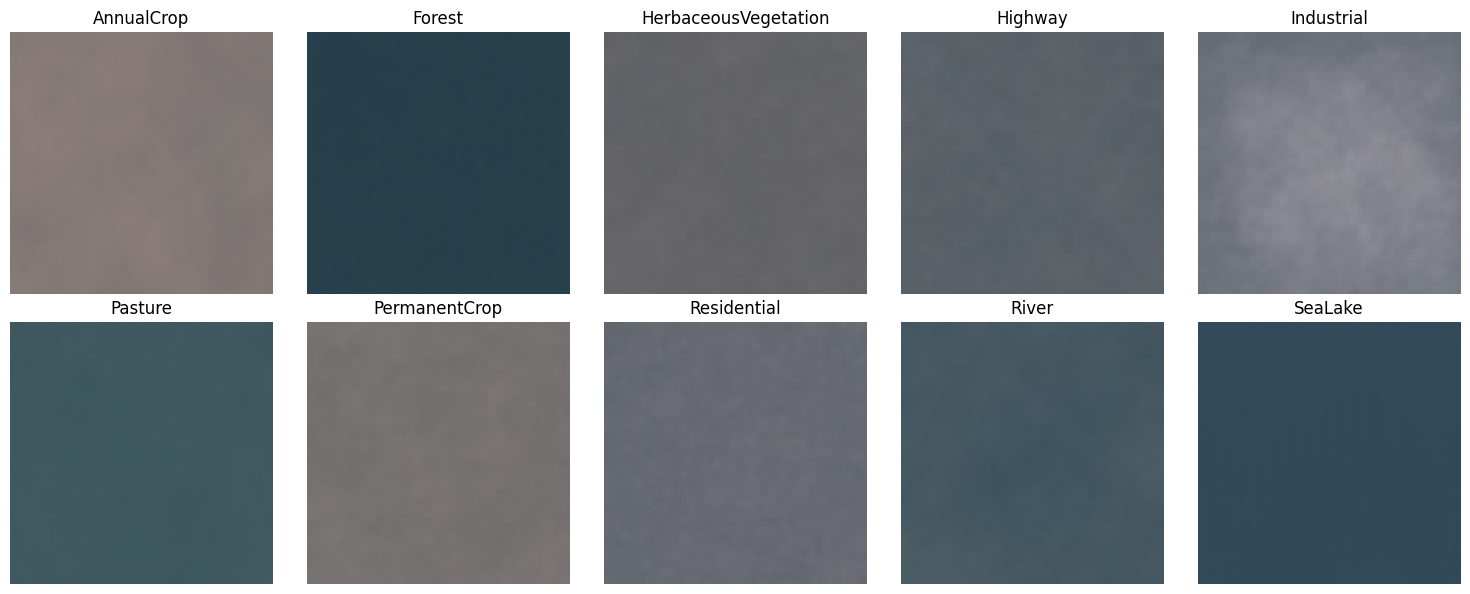

In [9]:
classes = sorted(os.listdir(DATA_DIR))

fig, axes = plt.subplots(2,5, figsize=(15,6))

for ax, class_name in zip(axes.flatten(), classes):

    class_path = os.path.join(DATA_DIR, class_name)

    images = []

    for img_name in os.listdir(class_path)[:200]:
        img = np.array(
            Image.open(os.path.join(class_path, img_name))
        )

        images.append(img)

    mean_img = np.mean(images, axis=0)

    ax.imshow(mean_img.astype(np.uint8))
    ax.set_title(class_name)
    ax.axis("off")

plt.tight_layout()
plt.show()

Preprocessing Data

Found 21600 images belonging to 10 classes.
Found 5400 images belonging to 10 classes.

Class Names:
['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']

Number of Classes:
10

Training Samples:
21600

Validation Samples:
5400

Image Batch Shape:
(32, 224, 224, 3)

Label Batch Shape:
(32,)

Pixel Value Range:
Min = 0.07450981
Max = 1.0


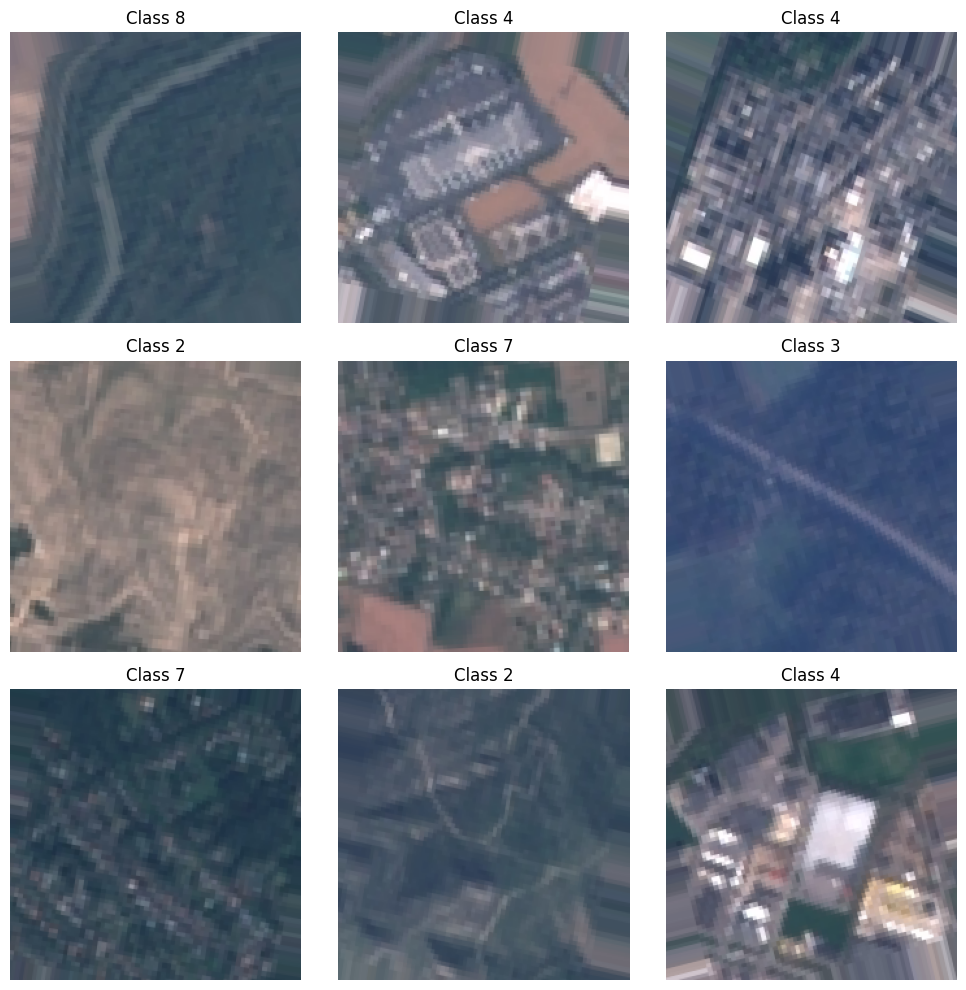

In [6]:
# ==========================================
# EUROSAT PREPROCESSING PIPELINE
# ==========================================


# ------------------------------------------
# Configuration
# ------------------------------------------

DATA_DIR = "/content/EuroSAT"

IMG_HEIGHT = 224
IMG_WIDTH = 224

BATCH_SIZE = 32
SEED = 42

# ------------------------------------------
# Training Data Generator
# ------------------------------------------

train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.20,
    rotation_range=20,
    horizontal_flip=True,
    zoom_range=0.10
)

# ------------------------------------------
# Validation Data Generator
# ------------------------------------------

val_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.20
)

# ------------------------------------------
# Create Training Dataset
# ------------------------------------------

train_data = train_datagen.flow_from_directory(
    DATA_DIR,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode="sparse",
    subset="training",
    shuffle=True,
    seed=SEED
)

# ------------------------------------------
# Create Validation Dataset
# ------------------------------------------

val_data = val_datagen.flow_from_directory(
    DATA_DIR,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode="sparse",
    subset="validation",
    shuffle=False,
    seed=SEED
)

# ------------------------------------------
# Dataset Summary
# ------------------------------------------

print("\nClass Names:")
print(list(train_data.class_indices.keys()))

print("\nNumber of Classes:")
print(len(train_data.class_indices))

print("\nTraining Samples:")
print(train_data.samples)

print("\nValidation Samples:")
print(val_data.samples)

# ------------------------------------------
# Inspect One Batch
# ------------------------------------------

images, labels = next(train_data)

print("\nImage Batch Shape:")
print(images.shape)

print("\nLabel Batch Shape:")
print(labels.shape)

print("\nPixel Value Range:")
print("Min =", images.min())
print("Max =", images.max())

# ------------------------------------------
# Visualize Sample Images
# ------------------------------------------

plt.figure(figsize=(10, 10))

for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.imshow(images[i])
    plt.title(f"Class {int(labels[i])}")
    plt.axis("off")

plt.tight_layout()
plt.show()

CNN Baseline Model

In [7]:
# ==========================================
# CNN BASELINE MODEL FOR EUROSAT
# ==========================================

import tensorflow as tf
from tensorflow.keras import layers, models

num_classes = len(train_data.class_indices)

# ------------------------------------------
# Build CNN Model
# ------------------------------------------

model = models.Sequential([

    # Input layer
    layers.Input(shape=(224, 224, 3)),

    # First conv block
    layers.Conv2D(32, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    # Second conv block
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    # Third conv block
    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    # Flatten + Dense layers
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),

    # Output layer
    layers.Dense(num_classes, activation='softmax')
])

# ------------------------------------------
# Compile Model
# ------------------------------------------

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# ------------------------------------------
# Model Summary
# ------------------------------------------

model.summary()

# ------------------------------------------
# Train Model
# ------------------------------------------

history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=10
)

# ------------------------------------------
# Evaluate Model
# ------------------------------------------

loss, acc = model.evaluate(val_data)
print(f"\nValidation Accuracy: {acc:.4f}")

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,170,250 (42.61 MB)

 Trainable params: 11,170,250 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
675/675 ━━━━━━━━━━━━━━━━━━━━ 284s 409ms/step - accuracy: 0.4413 - loss: 1.5090 - val_accuracy: 0.6457 - val_loss: 1.0381
Epoch 2/10
675/675 ━━━━━━━━━━━━━━━━━━━━ 273s 404ms/step - accuracy: 0.6085 - loss: 1.1147 - val_accuracy: 0.7078 - val_loss: 0.7954
Epoch 3/10
675/675 ━━━━━━━━━━━━━━━━━━━━ 271s 402ms/step - accuracy: 0.6625 - loss: 0.9502 - val_accuracy: 0.7411 - val_loss: 0.7397
Epoch 4/10
675/675 ━━━━━━━━━━━━━━━━━━━━ 267s 395ms/step - accuracy: 0.7048 - loss: 0.8424 - val_accuracy: 0.7404 - val_loss: 0.7031
Epoch 5/10
675/675 ━━━━━━━━━━━━━━━━━━━━ 268s 397ms/step - accuracy: 0.7248 - loss: 0.7868 - val_accuracy: 0.7906 - val_loss: 0.5907
Epoch 6/10
675/675 ━━━━━━━━━━━━━━━━━━━━ 266s 394ms/step - accuracy: 0.7435 - loss: 0.7365 - val_accuracy: 0.7802 - val_loss: 0.5988
Epoch 7/10
675/675 ━━━━━━━━━━━━━━━━━━━━ 267s 396ms/step - accuracy: 0.7627 - loss: 0.6877 - val_accuracy: 0.7457 - val_loss: 0.7295
Epoch 8/10
675/675 ━━━━━━━━━━━━━━━━━━━━ 270s 400ms/step - accuracy: 0.7835 -

CONFUSION MATRIX + EVALUATION

169/169 ━━━━━━━━━━━━━━━━━━━━ 7s 40ms/step


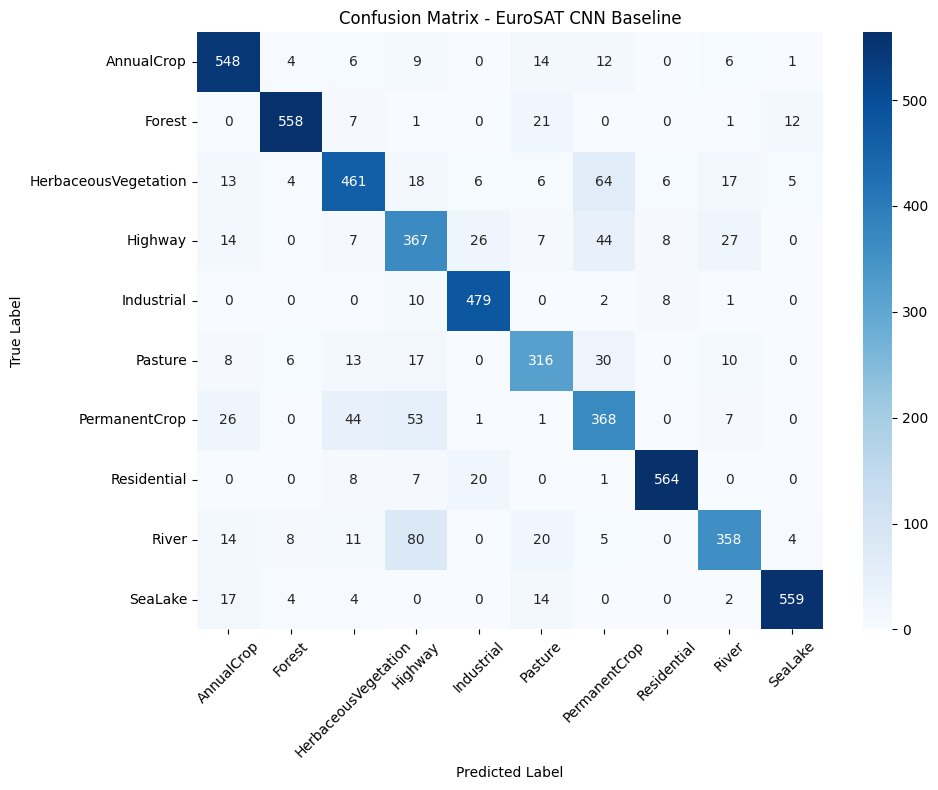


Classification Report:

                      precision    recall  f1-score   support

          AnnualCrop       0.86      0.91      0.88       600
              Forest       0.96      0.93      0.94       600
HerbaceousVegetation       0.82      0.77      0.79       600
             Highway       0.65      0.73      0.69       500
          Industrial       0.90      0.96      0.93       500
             Pasture       0.79      0.79      0.79       400
       PermanentCrop       0.70      0.74      0.72       500
         Residential       0.96      0.94      0.95       600
               River       0.83      0.72      0.77       500
             SeaLake       0.96      0.93      0.95       600

            accuracy                           0.85      5400
           macro avg       0.84      0.84      0.84      5400
        weighted avg       0.85      0.85      0.85      5400



In [10]:
# ------------------------------------------
# Get true labels and predictions
# ------------------------------------------

y_true = val_data.classes  # true labels from generator

# Predict probabilities
y_pred_probs = model.predict(val_data)

# Convert to class predictions
y_pred = np.argmax(y_pred_probs, axis=1)

# ------------------------------------------
# Class names
# ------------------------------------------

class_names = list(val_data.class_indices.keys())

# ------------------------------------------
# Confusion Matrix
# ------------------------------------------

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10,8))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - EuroSAT CNN Baseline")
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# ------------------------------------------
# Classification Report
# ------------------------------------------

print("\nClassification Report:\n")
print(classification_report(y_true, y_pred, target_names=class_names))

ResNet-50 Transfer Learning Model

In [13]:
# ==========================================
# RESNET-50 TRANSFER LEARNING (EUROSAT)
# ==========================================


# ------------------------------------------
# Number of classes
# ------------------------------------------

num_classes = len(train_data.class_indices)

# ------------------------------------------
# Load pretrained ResNet-50
# ------------------------------------------

base_model = tf.keras.applications.ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

# Freeze base model
base_model.trainable = False

# ------------------------------------------
# Build model
# ------------------------------------------

model = models.Sequential([

    base_model,
    layers.GlobalAveragePooling2D(),

    layers.Dense(256, activation="relu"),
    layers.Dropout(0.5),

    layers.Dense(num_classes, activation="softmax")
])

# ------------------------------------------
# Compile model
# ------------------------------------------

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# ------------------------------------------
# Model summary
# ------------------------------------------

model.summary()

# ------------------------------------------
# Train model
# ------------------------------------------

history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=10
)

# ------------------------------------------
# Evaluate model
# ------------------------------------------

loss, acc = model.evaluate(val_data)
print(f"\nValidation Accuracy: {acc:.4f}")

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,114,826 (91.99 MB)

 Trainable params: 527,114 (2.01 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

Epoch 1/10
675/675 ━━━━━━━━━━━━━━━━━━━━ 308s 434ms/step - accuracy: 0.1694 - loss: 2.2699 - val_accuracy: 0.2050 - val_loss: 2.1733
Epoch 2/10
675/675 ━━━━━━━━━━━━━━━━━━━━ 281s 417ms/step - accuracy: 0.2136 - loss: 2.1339 - val_accuracy: 0.2769 - val_loss: 2.0648
Epoch 3/10
675/675 ━━━━━━━━━━━━━━━━━━━━ 284s 420ms/step - accuracy: 0.2298 - loss: 2.0476 - val_accuracy: 0.3019 - val_loss: 1.9912
Epoch 4/10
675/675 ━━━━━━━━━━━━━━━━━━━━ 286s 424ms/step - accuracy: 0.2467 - loss: 1.9923 - val_accuracy: 0.2544 - val_loss: 1.9420
Epoch 5/10
675/675 ━━━━━━━━━━━━━━━━━━━━ 282s 418ms/step - accuracy: 0.2611 - loss: 1.9463 - val_accuracy: 0.2787 - val_loss: 1.8998
Epoch 6/10
675/675 ━━━━━━━━━━━━━━━━━━━━ 282s 418ms/step - accuracy: 0.2713 - loss: 1.9119 - val_accuracy: 0.2907 - val_loss: 1.8684
Epoch 7/10
675/675 ━━━━━━━━━━━━━━━━━━━━ 283s 419ms/step - accuracy: 0.2840 - loss: 1.8807 - val_accuracy: 0.3102 - val_loss: 1.8383
Epoch 8/10
675/675 ━━━━━━━━━━━━━━━━━━━━ 282s 418ms/step - accuracy: 0.2927 -

RESNET-50 EVALUATION

169/169 ━━━━━━━━━━━━━━━━━━━━ 15s 90ms/step
169/169 ━━━━━━━━━━━━━━━━━━━━ 14s 82ms/step - accuracy: 0.3370 - loss: 1.7668

Validation Loss: 1.7668
Validation Accuracy: 0.3370

Classification Report:

                      precision    recall  f1-score   support

          AnnualCrop       0.26      0.45      0.33       600
              Forest       0.00      0.00      0.00       600
HerbaceousVegetation       0.13      0.13      0.13       600
             Highway       0.50      0.00      0.00       500
          Industrial       0.71      0.82      0.76       500
             Pasture       0.00      0.00      0.00       400
       PermanentCrop       0.32      0.18      0.23       500
         Residential       0.39      0.64      0.48       600
               River       0.00      0.00      0.00       500
             SeaLake       0.31      0.98      0.47       600

            accuracy                           0.34      5400
           macro avg       0.26      0.32      0.24     

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


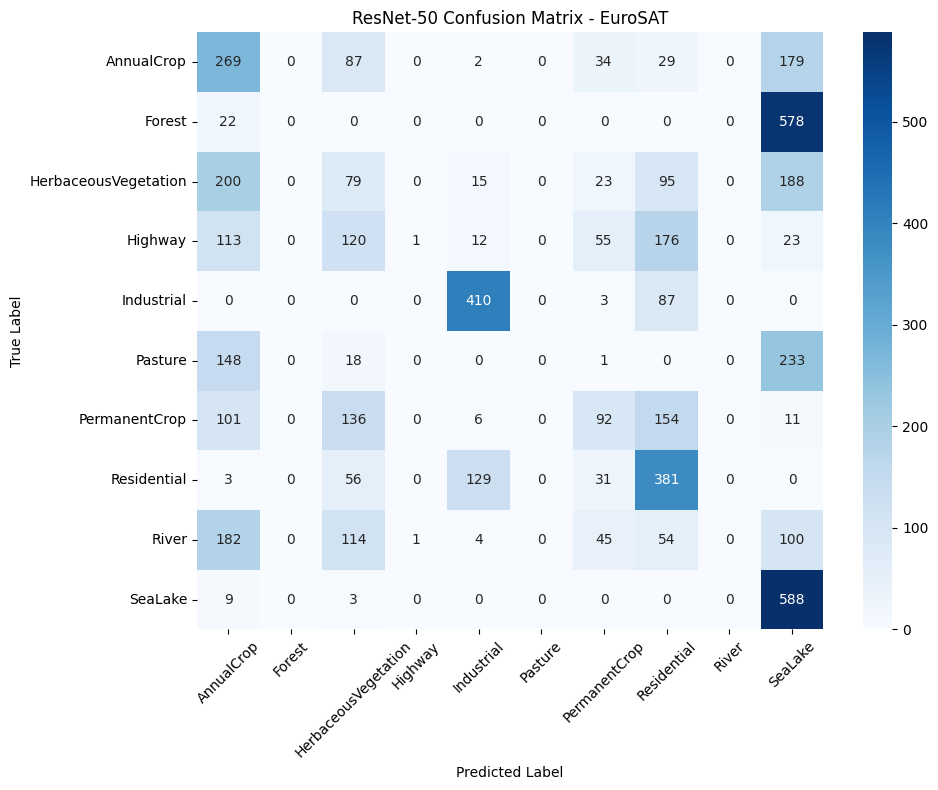


Classification Report:

                      precision    recall  f1-score   support

          AnnualCrop       0.26      0.45      0.33       600
              Forest       0.00      0.00      0.00       600
HerbaceousVegetation       0.13      0.13      0.13       600
             Highway       0.50      0.00      0.00       500
          Industrial       0.71      0.82      0.76       500
             Pasture       0.00      0.00      0.00       400
       PermanentCrop       0.32      0.18      0.23       500
         Residential       0.39      0.64      0.48       600
               River       0.00      0.00      0.00       500
             SeaLake       0.31      0.98      0.47       600

            accuracy                           0.34      5400
           macro avg       0.26      0.32      0.24      5400
        weighted avg       0.26      0.34      0.25      5400



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [15]:
# ==========================================
# RESNET-50 EVALUATION + CONFUSION MATRIX
# ==========================================


# ------------------------------------------
# CLASS NAMES
# ------------------------------------------

class_names = list(val_data.class_indices.keys())

# ------------------------------------------
# TRUE LABELS
# ------------------------------------------

y_true = val_data.classes

# ------------------------------------------
# PREDICTIONS
# ------------------------------------------

y_pred_probs = model.predict(val_data)
y_pred = np.argmax(y_pred_probs, axis=1)

# ------------------------------------------
# BASIC EVALUATION
# ------------------------------------------

loss, acc = model.evaluate(val_data)
print(f"\nValidation Loss: {loss:.4f}")
print(f"Validation Accuracy: {acc:.4f}")

# ------------------------------------------
# CLASSIFICATION REPORT
# ------------------------------------------

print("\nClassification Report:\n")
print(classification_report(y_true, y_pred, target_names=class_names))

# ------------------------------------------
# CONFUSION MATRIX
# ------------------------------------------

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10,8))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("ResNet-50 Confusion Matrix - EuroSAT")
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


ResNet 2

In [19]:
# ==========================================
# RESNET-50 PIPELINE (FIXED VERSION)
# EuroSAT - Transfer Learning
# ==========================================

# ------------------------------------------
# CONFIG
# ------------------------------------------

DATA_DIR = "/content/EuroSAT"

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42

# ------------------------------------------
# DATA GENERATORS (IMPORTANT FIX HERE)
# ------------------------------------------
# NOTE: NO rescale=1./255 !!!
# We use preprocess_input instead.

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input, #fixed preprocessing
    validation_split=0.2,
    rotation_range=20,
    horizontal_flip=True,
    zoom_range=0.1
)

val_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    validation_split=0.2
)

# ------------------------------------------
# TRAIN DATA
# ------------------------------------------

train_data = train_datagen.flow_from_directory(
    DATA_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="sparse",
    subset="training",
    seed=SEED,
    shuffle=True
)

# ------------------------------------------
# VALIDATION DATA
# ------------------------------------------

val_data = val_datagen.flow_from_directory(
    DATA_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="sparse",
    subset="validation",
    seed=SEED,
    shuffle=False
)

# ------------------------------------------
# CLASS INFO
# ------------------------------------------

num_classes = len(train_data.class_indices)

print("Classes:", list(train_data.class_indices.keys()))
print("Number of classes:", num_classes)

# ------------------------------------------
# BUILD RESNET-50 MODEL
# ------------------------------------------

base_model = ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

base_model.trainable = False  # freeze backbone

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(num_classes, activation="softmax")
])

# ------------------------------------------
# COMPILE
# ------------------------------------------

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

# ------------------------------------------
# TRAIN (FEATURE EXTRACTION PHASE)
# ------------------------------------------

history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=10
)

# ------------------------------------------
# EVALUATION (BEFORE FINE-TUNING)
# ------------------------------------------

loss, acc = model.evaluate(val_data)
print("\nValidation Accuracy (frozen):", acc)

Found 21600 images belonging to 10 classes.
Found 5400 images belonging to 10 classes.
Classes: ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']
Number of classes: 10


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,114,826 (91.99 MB)

 Trainable params: 527,114 (2.01 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

Epoch 1/10
675/675 ━━━━━━━━━━━━━━━━━━━━ 304s 433ms/step - accuracy: 0.7767 - loss: 0.6675 - val_accuracy: 0.9056 - val_loss: 0.2835
Epoch 2/10
675/675 ━━━━━━━━━━━━━━━━━━━━ 283s 419ms/step - accuracy: 0.8980 - loss: 0.3091 - val_accuracy: 0.9196 - val_loss: 0.2367
Epoch 3/10
675/675 ━━━━━━━━━━━━━━━━━━━━ 325s 423ms/step - accuracy: 0.9187 - loss: 0.2444 - val_accuracy: 0.9378 - val_loss: 0.1860
Epoch 4/10
675/675 ━━━━━━━━━━━━━━━━━━━━ 282s 417ms/step - accuracy: 0.9280 - loss: 0.2106 - val_accuracy: 0.9413 - val_loss: 0.1745
Epoch 5/10
675/675 ━━━━━━━━━━━━━━━━━━━━ 282s 417ms/step - accuracy: 0.9342 - loss: 0.1934 - val_accuracy: 0.9448 - val_loss: 0.1643
Epoch 6/10
675/675 ━━━━━━━━━━━━━━━━━━━━ 282s 418ms/step - accuracy: 0.9398 - loss: 0.1772 - val_accuracy: 0.9511 - val_loss: 0.1501
Epoch 7/10
675/675 ━━━━━━━━━━━━━━━━━━━━ 283s 419ms/step - accuracy: 0.9427 - loss: 0.1683 - val_accuracy: 0.9481 - val_loss: 0.1535
Epoch 8/10
675/675 ━━━━━━━━━━━━━━━━━━━━ 283s 419ms/step - accuracy: 0.9473 -

169/169 ━━━━━━━━━━━━━━━━━━━━ 26s 111ms/step
169/169 ━━━━━━━━━━━━━━━━━━━━ 15s 89ms/step - accuracy: 0.9574 - loss: 0.1276

Validation Loss: 0.1276
Validation Accuracy: 0.9574

Classification Report:

                      precision    recall  f1-score   support

          AnnualCrop       0.96      0.97      0.97       600
              Forest       0.97      0.97      0.97       600
HerbaceousVegetation       0.93      0.94      0.93       600
             Highway       0.93      0.92      0.92       500
          Industrial       0.96      0.98      0.97       500
             Pasture       0.97      0.93      0.95       400
       PermanentCrop       0.92      0.95      0.93       500
         Residential       0.99      0.97      0.98       600
               River       0.95      0.94      0.94       500
             SeaLake       0.99      0.99      0.99       600

            accuracy                           0.96      5400
           macro avg       0.96      0.96      0.96    

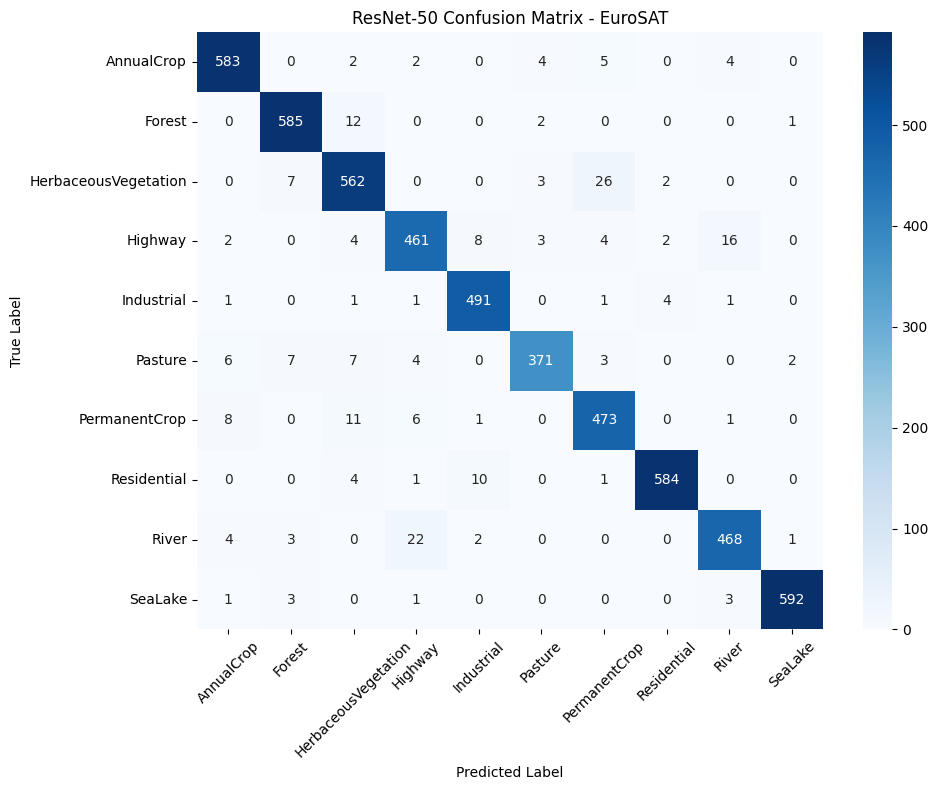

In [20]:
# ==========================================
# RESNET-50 EVALUATION + CONFUSION MATRIX
# ==========================================


# ------------------------------------------
# CLASS NAMES
# ------------------------------------------

class_names = list(val_data.class_indices.keys())

# ------------------------------------------
# TRUE LABELS
# ------------------------------------------

y_true = val_data.classes

# ------------------------------------------
# PREDICTIONS
# ------------------------------------------

y_pred_probs = model.predict(val_data)
y_pred = np.argmax(y_pred_probs, axis=1)

# ------------------------------------------
# BASIC EVALUATION
# ------------------------------------------

loss, acc = model.evaluate(val_data)
print(f"\nValidation Loss: {loss:.4f}")
print(f"Validation Accuracy: {acc:.4f}")

# ------------------------------------------
# CLASSIFICATION REPORT
# ------------------------------------------

print("\nClassification Report:\n")
print(classification_report(y_true, y_pred, target_names=class_names))

# ------------------------------------------
# CONFUSION MATRIX
# ------------------------------------------

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10,8))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("ResNet-50 Confusion Matrix - EuroSAT")
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


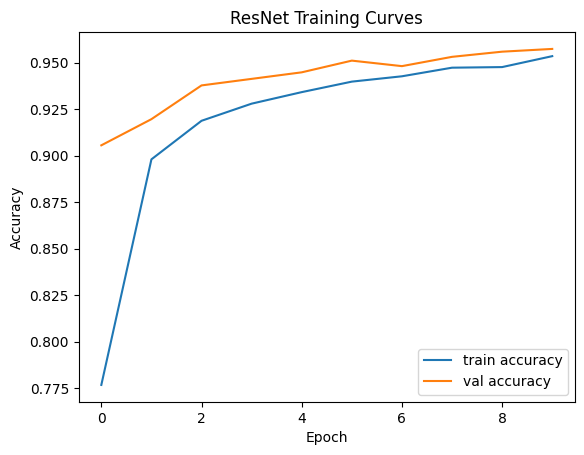

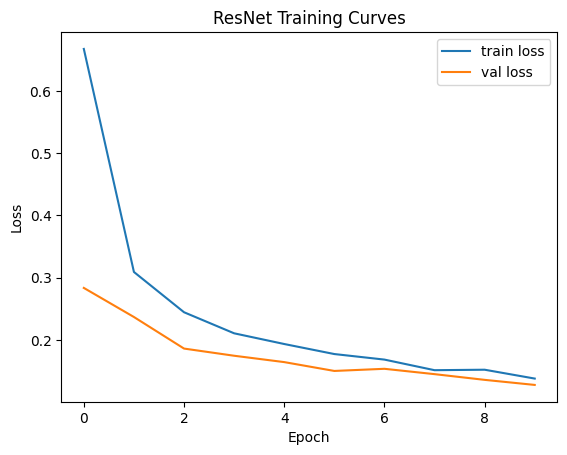

In [22]:
def plot_history(history, title):
    plt.plot(history.history['accuracy'], label='train accuracy')
    plt.plot(history.history['val_accuracy'], label='val accuracy')
    plt.title(title)
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.show()

    plt.plot(history.history['loss'], label='train loss')
    plt.plot(history.history['val_loss'], label='val loss')
    plt.title(title)
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()

plot_history(history, "ResNet Training Curves")